In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from romlab import FOM, POD, OfflinePhase, OnlinePhase, Plot

files_train = ["snapshots.txt", "c-trace.txt", "mesh_coor2.txt", "parameters.txt"]
files_test  = ['snapshots_test.txt', 'c-trace_test.txt','mesh_coor2_test.txt', 'parameters_test.txt']

fom = FOM(
    data_folder=ROOT / "data/2d/lambda-beta",
    filenames_train=files_train,
    filenames_test=files_test,
    mesh_file="mesh.vtk",
    param_cols=[0, 1, 2], seed = 42)
fom.info()

100 train, 100 test
dofs: velocity 4690, c-trace 2345, mesh_coor2 2345


In [2]:
pod = POD(fom, centering = True, eps=1e-6)
pod.compute_basis()
pod.info()

velocity: 46/100 modes
c-trace: 47/100 modes
mesh_coor2: 26/100 modes


In [7]:
offline = OfflinePhase(fom, pod, x_scaler="minmax")
offline.train_rom()
offline.info()

velocity: 0.596**2 * RBF(length_scale=[0.255, 0.314, 35.2])
c-trace: 27.8**2 * RBF(length_scale=[0.227, 0.225, 0.00366])
mesh_coor2: 0.928**2 * RBF(length_scale=[0.361, 0.424, 0.00296])


In [8]:
online = OnlinePhase(fom, pod, offline)
online.reconstruct_sol()
online.info()

velocity (relative error) = 6.19e-05
c-trace (relative error) = 9.31e-04
mesh_coor2 (relative error) = 7.97e-06


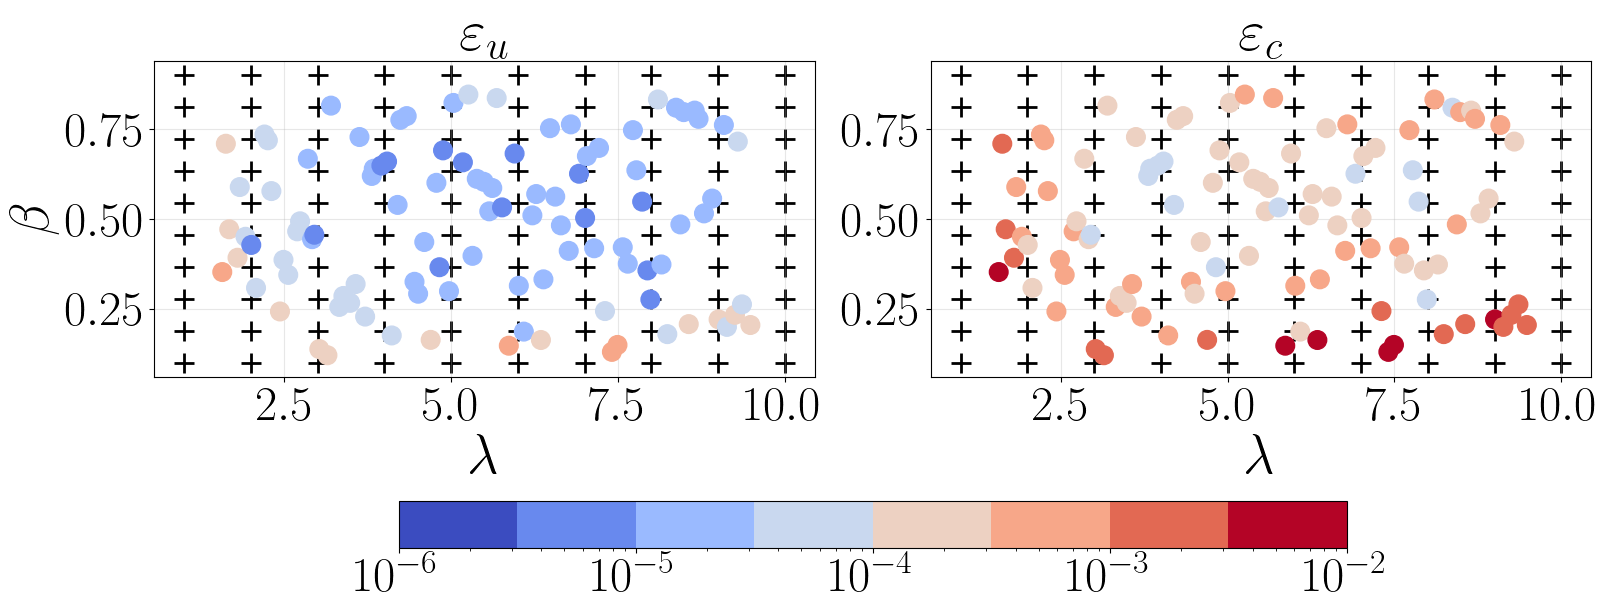

In [9]:
plot = Plot(fom, online)
plot.plot_relative_error()